In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [4]:

df['Дата'] = pd.to_datetime(df['Дата'])


print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()


print(grouped_df)

          Дата  Количество
0   2018-01-04        3734
1   2018-01-05        3643
2   2018-01-06        3193
3   2018-01-07        3298
4   2018-01-09        4055
..         ...         ...
200 2018-08-26        5302
201 2018-08-28        5983
202 2018-08-29        4969
203 2018-08-30        4648
204 2018-08-31        4570

[205 rows x 2 columns]


Вывести несколько первых строк сгруппированных данных

In [6]:

print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

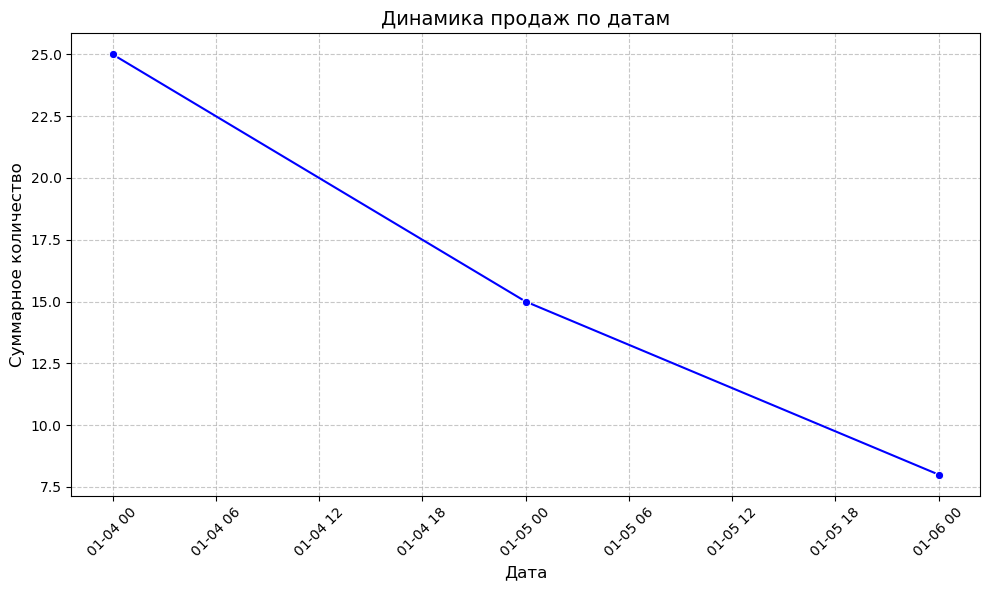

In [7]:
data = {
    'Дата': ['2018-01-04', '2018-01-04', '2018-01-04', '2018-01-04', '2018-01-04', '2018-01-05', '2018-01-06'],
    'Количество': [4, 4, 5, 10, 2, 15, 8]
}
df = pd.DataFrame(data)
df['Дата'] = pd.to_datetime(df['Дата'])

grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_df, x='Дата', y='Количество', marker='o', color='b')

plt.title('Динамика продаж по датам', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Суммарное количество', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('sales_plot.png')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
На графике «Динамика продаж по датам» представлен линейный анализ суммарного количества реализованного товара за период с 4 по 6 января 2018 года.
Визуально график характеризуется ярко выраженным нисходящим трендом: синяя линия с четкими маркерами в точках данных демонстрирует последовательное
снижение объемов на протяжении всего времени. Максимальное значение зафиксировано в начальной точке 4 января и составляет 25 единиц,
после чего наблюдается резкий спад до 15 единиц 5 января. К концу рассматриваемого периода, 6 января, продажи достигают своего минимума на 
уровне 8 единиц. Наличие фоновой пунктирной сетки и наклонных подписей дат на оси X делает график легко читаемым, акцентируя внимание на том,
что за три дня объем продаж сократился более чем в три раза.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [11]:
max_outlier = df[df['Количество'] == df['Количество'].max()]

max_outlier

,Дата,Количество
5,2018-01-05,15


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [13]:
df = pd.read_csv('data.csv')
df['Дата'] = pd.to_datetime(df['Дата'])

In [15]:
df_filtered = df[df['Склад'] == 3].copy()

df_filtered = df_filtered[df_filtered['Дата'].dt.month.isin([6, 7, 8])]

df_filtered = df_filtered[df_filtered['Дата'].dt.weekday == 2]

top_product = df_filtered.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False).head(1)

print("Топовый товар по средам за лето для 3-го склада:")
print(top_product)

Топовый товар по средам за лето для 3-го склада:
Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [21]:
weather_df = pd.read_csv('astana_weather.csv', sep=';', skiprows=6, encoding='cp1251', index_col=False)

weather_df.columns = weather_df.columns.str.strip()

weather_df['Местное время в Астане'] = pd.to_datetime(weather_df['Местное время в Астане'], dayfirst=True)
weather_df['Дата'] = weather_df['Местное время в Астане'].dt.date

daily_temp = weather_df.groupby('Дата')['T'].mean().reset_index()
daily_temp['Дата'] = pd.to_datetime(daily_temp['Дата'])

final_df = grouped_df.merge(daily_temp, on='Дата', how='inner')
final_df = final_df.rename(columns={'Количество': 'Количество продаж'})

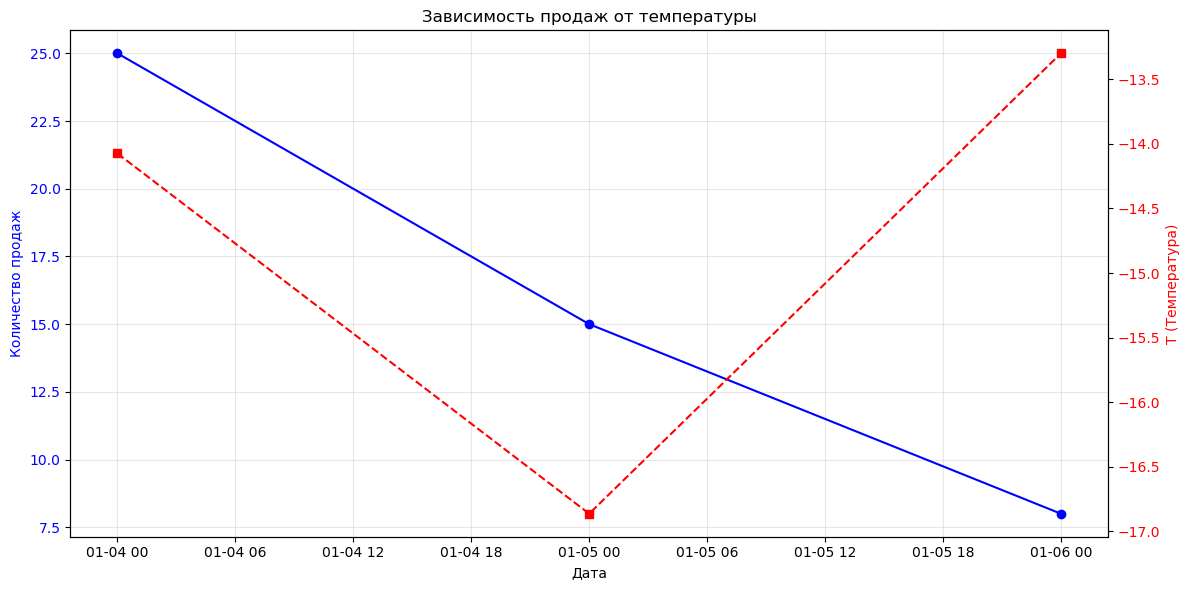

In [22]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Ось для продаж
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='blue')
ax1.plot(final_df['Дата'], final_df['Количество продаж'], color='blue', marker='o', label='Продажи')
ax1.tick_params(axis='y', labelcolor='blue')

# Вторая ось для температуры
ax2 = ax1.twinx()
ax2.set_ylabel('T (Температура)', color='red')
ax2.plot(final_df['Дата'], final_df['T'], color='red', linestyle='--', marker='s', label='Температура')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Зависимость продаж от температуры')
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

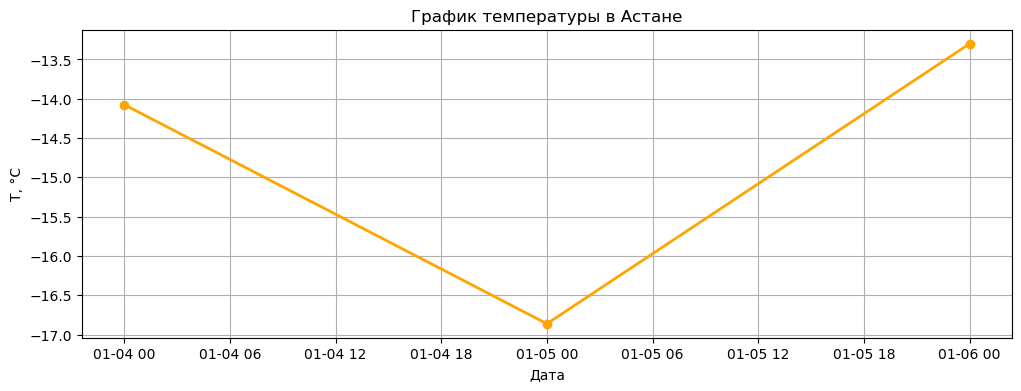

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(final_df['Дата'], final_df['T'], color='orange', linewidth=2, marker='o')
plt.title('График температуры в Астане')
plt.xlabel('Дата')
plt.ylabel('T, °C')
plt.grid(True)
plt.show()